In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/awsaf49
/kaggle/input/datasets/awsaf49/mnist-dataset
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/2
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/5
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/8
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/0
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/3
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/1
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/4
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/9
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/6
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing
/kaggle/input/datasets/awsaf49/mnist-dataset/

In [2]:
import tensorflow as tf

train_dir = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels=None,
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=128,
    shuffle=True
)

for images in train_ds.take(1):
    print(images.shape)

2026-06-14 13:35:43.348754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781444143.600472      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781444143.672851      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781444144.266234      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781444144.266295      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781444144.266299      58 computation_placer.cc:177] computation placer alr

Found 60000 files.


2026-06-14 13:38:35.269586: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


(128, 28, 28, 1)


In [3]:
train_ds = train_ds.map(lambda x: x / 255.0)

for images in train_ds.take(1):
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())

Min: 0.0
Max: 1.0


In [4]:
plt.figure(figsize=(8,4))

for images in train_ds.take(1):
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.axis("off")

plt.show()

NameError: name 'plt' is not defined

In [7]:
import matplotlib.pyplot as plt

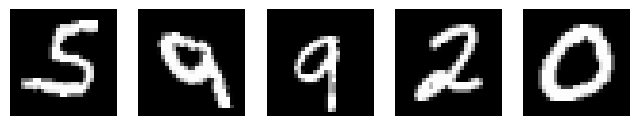

In [8]:
plt.figure(figsize=(8,4))

for images in train_ds.take(1):
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.axis("off")

plt.show()

In [14]:
import tensorflow as tf

def add_noise(images):
    noise = tf.random.normal

In [17]:
def add_noise(images):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=0.5)
    noisy_images = images + noise
    noisy_images = tf.clip_by_value(noisy_images, 0., 1.)
    return noisy_images

train_noisy = train_ds.map(add_noise)

In [18]:
from tensorflow.keras import layers, models

autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),

    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),

    # Decoder
    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),

    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
])

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
train_pairs = tf.data.Dataset.zip((train_noisy, train_ds))

history = autoencoder.fit(
    train_pairs.map(lambda noisy, clean: (noisy, clean)),
    epochs=5
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 306ms/step - loss: 0.2873
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - loss: 0.2651
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - loss: 0.2645
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - loss: 0.2643
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 0.2642


In [20]:
for images in train_ds.take(1):
    clean_images = images[:5]

noisy_images = add_noise(clean_images)

denoised_images = autoencoder.predict(noisy_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


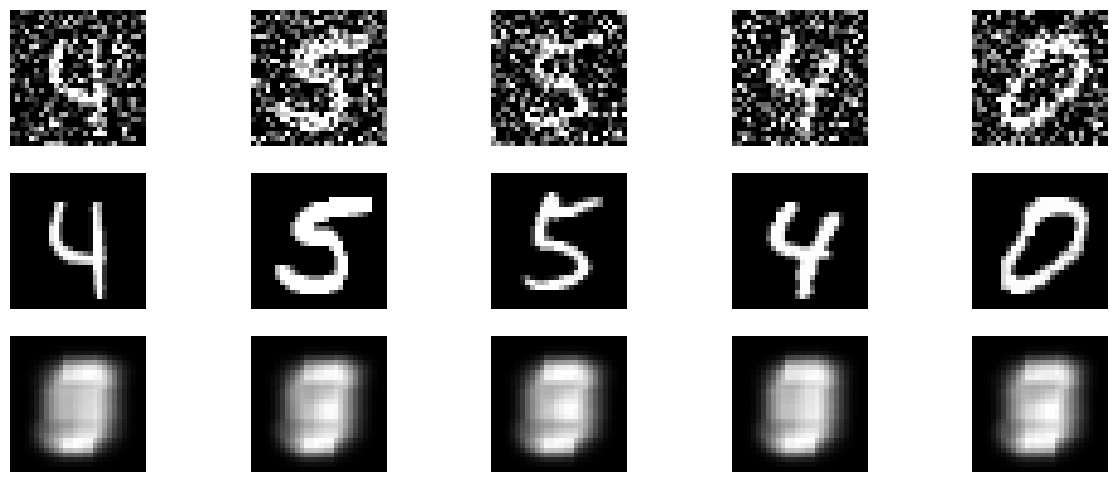

In [21]:
plt.figure(figsize=(15,6))

for i in range(5):

    # Noisy
    plt.subplot(3,5,i+1)
    plt.imshow(noisy_images[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

    # Clean
    plt.subplot(3,5,i+6)
    plt.imshow(clean_images[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

    # Denoised
    plt.subplot(3,5,i+11)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

In [22]:
print("""
Conclusion:
The autoencoder was trained to remove noise from MNIST digit images.
The model successfully learned compressed representations of the images
and reconstructed cleaner versions from noisy inputs.
""")


Conclusion:
The autoencoder was trained to remove noise from MNIST digit images.
The model successfully learned compressed representations of the images
and reconstructed cleaner versions from noisy inputs.

